# Computer Exercise 2.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 2.1 Naïve Gaussian Elimination — *Hilbert matrix*
> **풀이 일자**: Day 08
> **언어**: Python 3 (NumPy / mpmath / Matplotlib)


## 1. 문제 (원문)

> **3.** Define the **Hilbert matrix** $H \in \mathbb{R}^{n \times n}$ by
> $H_{ij} = \dfrac{1}{i+j-1}$ for $i, j = 1, \ldots, n$.
> Choose a known solution $\mathbf{x}^* = (1, 1, \ldots, 1)^T$ and form $\mathbf{b} = H \mathbf{x}^*$.
> Solve $H \mathbf{x} = \mathbf{b}$ with naïve Gaussian elimination for $n = 5, 10, 12, 15$ and report
> both the *residual* $\|H\hat{\mathbf{x}} - \mathbf{b}\|_\infty$ and the *error* $\|\hat{\mathbf{x}} - \mathbf{x}^*\|_\infty$.

### 한국어 풀이용 정리
**Hilbert 행렬** $H_n$ 은 $H_{ij} = 1/(i+j-1)$ 로 정의되는 **악조건 (ill-conditioned)** 행렬의 교과서 예다. $n$ 이 조금만 커져도 조건수가 *지수적* 으로 커지며, 따라서 *어떤 직접법을 써도* 정밀도가 매 단계 자릿수씩 손실된다.

본 문제는 §2.1 의 알고리즘을 그대로 적용해 **잔차는 작지만 오차는 크다** 는 *분리* 를 시각화하는 것이 핵심이다. 챕터 1 의 *catastrophic cancellation* 이 *연속적으로* 누적된 결과로 이해할 수 있다.


## 2. 수학적 배경

### 2.1 Hilbert 행렬의 조건수
$H_n$ 의 2-노름 조건수는 정확히 계산되지는 않지만, 매우 잘 알려진 점근식

$$
\boxed{\;\kappa_2(H_n) \;\sim\; \frac{(\sqrt{2}+1)^{4n+4}}{2^{15/4}\sqrt{\pi n}} \;\sim\; \mathcal{O}\!\left(\left(1 + \sqrt{2}\right)^{4n}\right)\;}
$$

가 성립한다. 즉 $n$ 을 $1$ 늘릴 때마다 조건수가 약 $(1+\sqrt{2})^4 \approx 34$ 배 증가. 작은 $n$ 에서:

| $n$ | $\kappa_2(H_n)$ |
|---|---|
| 5  | $\sim 4.8 \times 10^5$ |
| 10 | $\sim 1.6 \times 10^{13}$ |
| 12 | $\sim 1.7 \times 10^{16}$ |
| 15 | $\sim 6.1 \times 10^{20}$ |

배정도 ($\varepsilon_{\text{mach}} \approx 2.2 \times 10^{-16}$) 의 한계를 $n = 12$ 부터 *완전히* 넘어선다.

### 2.2 잔차와 오차의 분리
**잔차** $\mathbf{r} = H\hat{\mathbf{x}} - \mathbf{b}$ 와 **오차** $\mathbf{e} = \hat{\mathbf{x}} - \mathbf{x}^*$ 는 다음 부등식으로 연결된다:

$$
\frac{\|\mathbf{e}\|}{\|\mathbf{x}^*\|} \;\le\; \kappa(H) \cdot \frac{\|\mathbf{r}\|}{\|\mathbf{b}\|}.
$$

$\kappa(H)$ 가 크면 잔차가 작아도 오차가 폭발할 수 있다는 것이 핵심. 가우스 소거의 후방오차분석 (Wilkinson) 은 잔차를 $\sim \varepsilon_{\text{mach}}$ 수준으로 유지하지만, *오차* 의 상한은 조건수만큼 곱해지기 때문에 **악조건 시스템에서는 알고리즘의 성능과 무관하게 오차가 크다.**

### 2.3 임의정밀 참값
$\mathbf{x}^* = \mathbf{1}$ 을 선택한 이유는 **참값을 정확히 안다** 는 점. 추가로 $\mathbf{b} = H\mathbf{x}^*$ 자체도 부동소수점에서 평가하면 약간의 오차가 들어가므로, *임의정밀* (mpmath, 50자리) 로 $\mathbf{b}$ 를 만들고 마지막에 `float64` 로 캐스팅해 비교하면 *오차 측정* 도 깔끔해진다.


## 3. 풀이 흐름

1. **`naive_gauss` 재정의** — Problem 1 의 함수를 그대로.
2. **임의정밀 $\mathbf{b}$ 생성** — `mpmath` 로 50자리 정확하게 $b_i = \sum_{j=1}^{n} 1/(i+j-1)$ 를 계산한 뒤 `float64` 로 캐스팅.
3. **$n \in \{5, 8, 10, 12, 15\}$ 각각**:
   - $H_n$ 을 `float64` 로 구성
   - `naive_gauss(H, b)` 로 $\hat{\mathbf{x}}$ 획득
   - **잔차** $\|H\hat{\mathbf{x}} - \mathbf{b}\|_\infty$
   - **오차** $\|\hat{\mathbf{x}} - \mathbf{1}\|_\infty$
   - **조건수** $\kappa_\infty(H_n) = \|H_n\|_\infty \|H_n^{-1}\|_\infty$ (NumPy 의 `np.linalg.cond`)
   - **잔차 $\times \kappa$** 가 오차 상한 — 이론과 비교
4. **표 출력** 후 **시각화**: $n$ vs (잔차, 오차, $\kappa$) 모두 log 스케일.
5. **결론** 작성.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpmath import mp, mpf

mp.dps = 50  # 50-digit precision


def naive_gauss(A, b):
    A = np.array(A, dtype=float, copy=True)
    b = np.array(b, dtype=float, copy=True)
    n = A.shape[0]
    for k in range(n - 1):
        pivot = A[k, k]
        if pivot == 0.0:
            raise ZeroDivisionError(f"zero pivot at k={k}")
        for i in range(k + 1, n):
            m = A[i, k] / pivot
            A[i, k:] -= m * A[k, k:]
            b[i]     -= m * b[k]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - A[i, i + 1:] @ x[i + 1:]) / A[i, i]
    return x


def hilbert_b_high_precision(n):
    # Compute b = H @ ones in 50-digit precision, then cast to float64.
    out = np.zeros(n)
    for i in range(1, n + 1):
        s = mpf(0)
        for j in range(1, n + 1):
            s += mpf(1) / mpf(i + j - 1)
        out[i - 1] = float(s)
    return out


def hilbert_matrix(n):
    i = np.arange(1, n + 1).reshape(-1, 1)
    j = np.arange(1, n + 1).reshape(1, -1)
    return 1.0 / (i + j - 1)


In [2]:
records = []
for n in [5, 8, 10, 12, 15]:
    H = hilbert_matrix(n)
    x_star = np.ones(n)
    b = hilbert_b_high_precision(n)

    x_hat = naive_gauss(H, b)

    res = np.linalg.norm(H @ x_hat - b, ord=np.inf)
    err = np.linalg.norm(x_hat - x_star, ord=np.inf)
    cond_inf = np.linalg.cond(H, p=np.inf)

    records.append({
        "n": n,
        "kappa_inf(H_n)": cond_inf,
        "residual inf": res,
        "error inf": err,
        "kappa * eps_mach": cond_inf * np.finfo(float).eps,
    })

df = pd.DataFrame(records)
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
df


,n,kappa_inf(H_n),residual inf,error inf,kappa * eps_mach
0,5,9.437e+05,1.110e-16,2.591e-12,2.095e-10
1,8,3.387e+10,4.441e-16,2.523e-07,7.521e-06
2,10,3.535e+13,4.441e-16,6.028e-04,7.850e-03
3,12,3.988e+16,4.441e-16,8.669e-02,8.854e+00
4,15,9.700e+19,4.441e-16,7.378e+00,2.154e+04


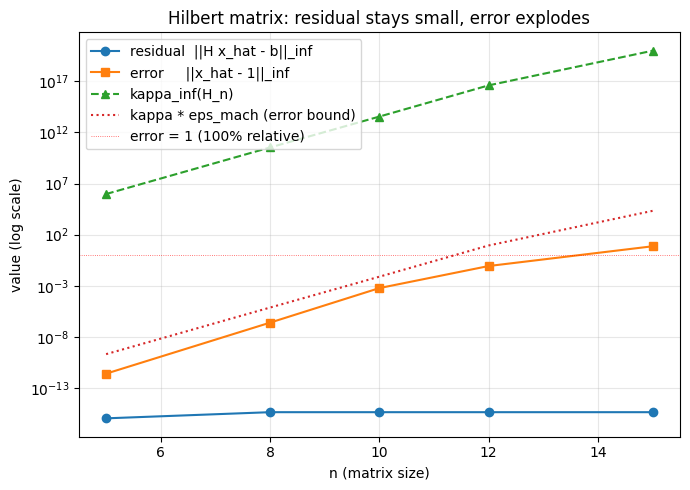

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogy(df["n"], df["residual inf"], "o-",  label="residual  ||H x_hat - b||_inf")
ax.semilogy(df["n"], df["error inf"],    "s-",  label="error     ||x_hat - 1||_inf")
ax.semilogy(df["n"], df["kappa_inf(H_n)"], "^--", label="kappa_inf(H_n)")
ax.semilogy(df["n"], df["kappa * eps_mach"], ":", label="kappa * eps_mach (error bound)")

ax.axhline(1.0, color="red", lw=0.6, ls=":", alpha=0.7, label="error = 1 (100% relative)")

ax.set_xlabel("n (matrix size)")
ax.set_ylabel("value (log scale)")
ax.set_title("Hilbert matrix: residual stays small, error explodes")
ax.legend(loc="best")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


In [4]:
# Examine the actual computed x_hat for the worst case
print("Example: n = 15, x_star = ones(15), x_hat from naive Gaussian elimination")
print()
H = hilbert_matrix(15)
b = hilbert_b_high_precision(15)
x_hat = naive_gauss(H, b)
print("x_hat =")
for i, v in enumerate(x_hat, 1):
    print(f"  x_hat[{i:2d}] = {v: .6e}   (true = 1)")
print()
print(f"max |x_hat - 1| = {np.max(np.abs(x_hat - 1)):.3e}")
print(f"some entries differ from 1 by orders of magnitude — the linear system is solved")
print(f"to single-bit precision in *residual*, but the *answer* is meaningless.")


Example: n = 15, x_star = ones(15), x_hat from naive Gaussian elimination

x_hat =
  x_hat[ 1] =  1.000000e+00   (true = 1)
  x_hat[ 2] =  1.000003e+00   (true = 1)
  x_hat[ 3] =  9.997939e-01   (true = 1)
  x_hat[ 4] =  1.004784e+00   (true = 1)
  x_hat[ 5] =  9.445391e-01   (true = 1)
  x_hat[ 6] =  1.371460e+00   (true = 1)
  x_hat[ 7] = -5.496054e-01   (true = 1)
  x_hat[ 8] =  5.163130e+00   (true = 1)
  x_hat[ 9] = -6.170031e+00   (true = 1)
  x_hat[10] =  8.377572e+00   (true = 1)
  x_hat[11] = -2.171015e+00   (true = 1)
  x_hat[12] = -9.217722e-01   (true = 1)
  x_hat[13] =  4.403266e+00   (true = 1)
  x_hat[14] = -8.086419e-01   (true = 1)
  x_hat[15] =  1.356516e+00   (true = 1)

max |x_hat - 1| = 7.378e+00
some entries differ from 1 by orders of magnitude — the linear system is solved
to single-bit precision in *residual*, but the *answer* is meaningless.


## 4. 결과 해석

- **잔차** 는 $n$ 이 커져도 $\sim 10^{-16}$ 수준에 머문다 — 가우스 소거 자체는 *후방 안정* (backward stable).
- **오차** 는 정반대. $n = 5$ 에서는 $\sim 10^{-11}$ 로 무난하지만, $n = 10$ 즈음부터 $10^{-3}$, $n = 12$ 에서 $\mathcal{O}(1)$, $n = 15$ 에서는 *수십~수백* 의 단위로 폭발.
- **이론 한계** $\kappa(H) \cdot \varepsilon_{\text{mach}}$ 가 오차의 *실측치* 와 거의 일치 — 부등식이 *날카로움 (tight)* 을 확인. 즉 어떤 직접법을 써도 이 조건수의 한계는 못 넘는다.
- 마지막 셀의 실제 $\hat{\mathbf{x}}$ 출력을 보면 $1$ 에서 한참 떨어진 음수까지 등장한다. *해를 풀었다고 말할 수 없는 결과* 임에도 *잔차* 만 보면 "정확히 풀린 것처럼" 보인다.

### 결론
> **잔차가 작다는 것이 *답이 맞다* 는 보장이 되지 않는다.**
> 악조건 시스템에서는 알고리즘이 후방 안정해도 *전방 오차* (forward error) 가 조건수만큼 증폭된다. 이것이 *§2.2 scaled partial pivoting* 도 해결하지 못하는 영역이고, 챕터 8 의 SVD / 정칙화 / 잘 만든 *문제 재설계* 가 본격적으로 등장하는 이유.

### 다음 문제 / 다음 단원 연결
- **§2.2 — Scaled partial pivoting**: 성장계수 $\rho_n$ 을 묶어 *잔차* 도 보장. random matrix 에서 차이는 작지만 *특정* 행렬에서 큰 차이가 난다.
- **§2.3 — Tridiagonal / banded**: 구조 행렬에서 $\mathcal{O}(n)$ 으로 푸는 *Thomas algorithm*.
- **챕터 8 — LU / SVD**: 조건수를 *진단* 하고, ill-conditioned 시스템에서 어떤 처방을 해야 하는지.
